In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def getStructuringElement(shape: str, size: int) -> np.ndarray:
    shape = shape.lower().strip()
    if shape == 'rect':
        return cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    elif shape == 'disk':
        return cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(size, size))
    elif shape == 'cross':
        return cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))
    elif shape == 'horizontal':
        kernel = np.zeros((1, size), dtype=np.uint8)
        kernel[0, :] = 1
        return kernel
    elif shape == 'vertical':
        kernel = np.zeros((size, 1), dtype=np.uint8)
        kernel[:, 0] = 1
        return kernel

def load_binary(path: str, threshold: int = 127) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
    return binary


def dilate(image: np.ndarray, shape: str, size: int):
    kernel = getStructuringElement(shape, size)
    return cv2.dilate(image, kernel)


def erode(image: np.ndarray, shape: str, size: int):
    kernel = getStructuringElement(shape, size)
    return cv2.erode(image, kernel)

In [27]:
IMAGE_PATH = "original_image.png" 
SHAPE      = "horizontal"   # 'rect' | 'disk' | 'cross'
KERNEL_SIZE = 15


original_image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
_, binary_image = cv2.threshold(original_image, 127, 255, cv2.THRESH_BINARY)

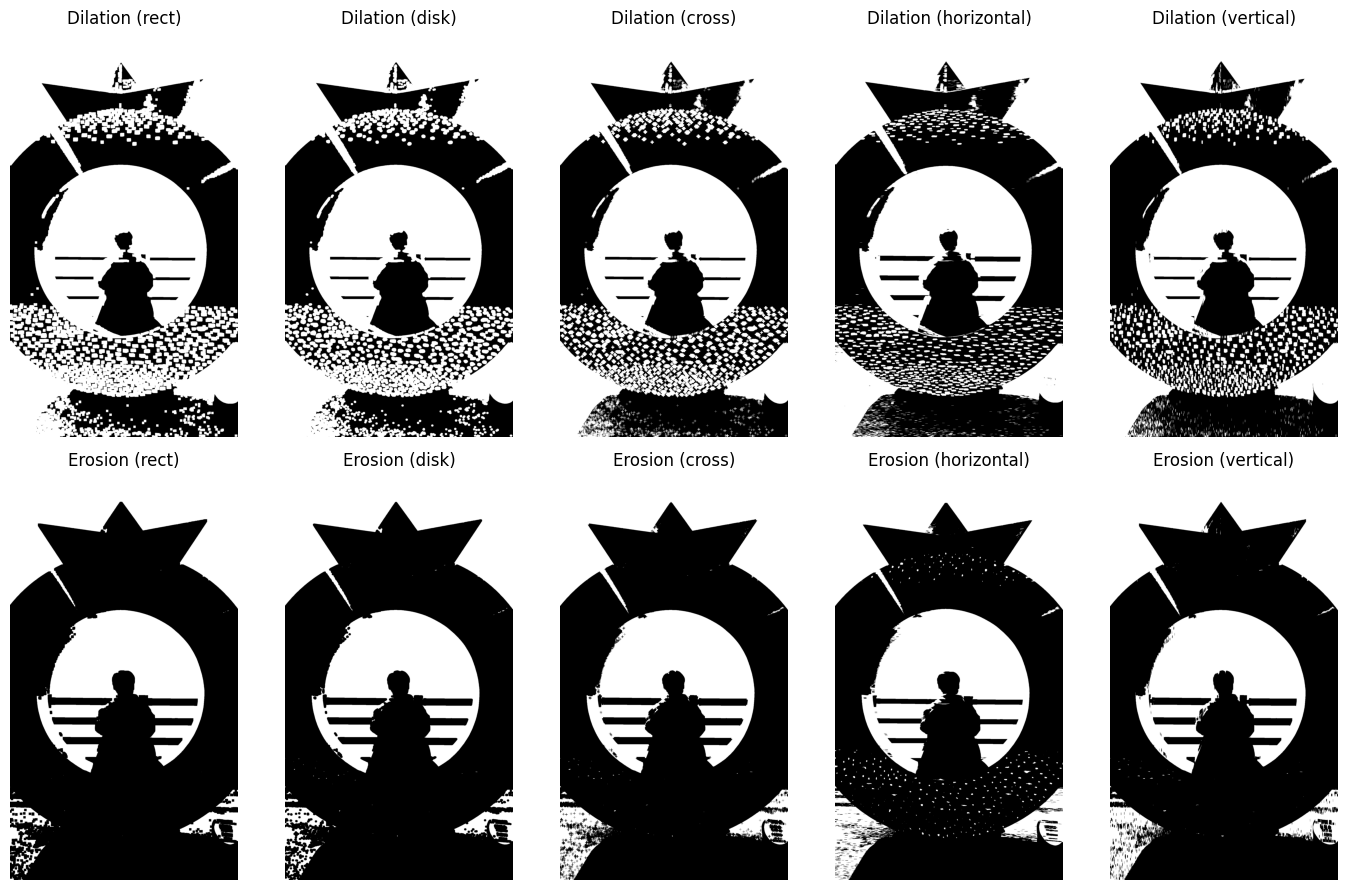

In [29]:
shapes = ['rect', 'disk', 'cross', 'horizontal', 'vertical']

fig, axes = plt.subplots(2, 5, figsize=(14, 9))

for col, shape in enumerate(shapes):
    d = dilate(binary_image, shape, KERNEL_SIZE)
    e = erode(binary_image, shape, KERNEL_SIZE)

    axes[0, col].imshow(d, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(f'Dilation ({shape})', fontsize=12)
    axes[0, col].axis('off')

    axes[1, col].imshow(e, cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_title(f'Erosion ({shape})', fontsize=12)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()